In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
import pandas as pd

file_path = r"C:\Users\user\OneDrive\Desktop\INTERNSHIP\archive\Housing.csv"

df = pd.read_csv(file_path)

# 2. Display the first 10 rows
print("--- First 10 Rows of the Dataset ---")
display(df.head(10))

# 3. Check how many rows and columns are there
print("\n--- Dataset Shape ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# 4. Identify target and features
print("\n--- Target & Feature Identification ---")
print("Target Column (What we want to predict): 'price'")
print(f"Feature Columns (Variables used to predict): {list(df.columns.drop('price'))}")

# 5. Check for missing values in each column
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows of the Dataset ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Shape ---
Total Rows: 545
Total Columns: 13

--- Target & Feature Identification ---
Target Column (What we want to predict): 'price'
Feature Columns (Variables used to predict): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [16]:
# 1. Remove duplicate rows, if any
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found and removed: {duplicate_count}")
df_cleaned = df.drop_duplicates()

# 2. Convert categorical columns (yes/no fields & furnishing status) into numeric form using one-hot encoding
# This dynamically finds all text-based columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to be converted: {categorical_cols}")

# Applying One-Hot Encoding
# drop_first=True converts yes/no into 1/0 and avoids multi-collinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 3. Check the final columns after encoding
print("\n--- Cleaned & Encoded Dataset Preview ---")
display(df_encoded.head())
print(f"\nNew Dataset Shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")

Number of duplicate rows found and removed: 0

Categorical columns to be converted: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- Cleaned & Encoded Dataset Preview ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



New Dataset Shape: 545 rows, 14 columns


In [17]:
# 1. Separate features (X) and target variable (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# 2. Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to easily calculate evaluation metrics
def calculate_performance(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2

# 3. Train and evaluate Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mae, lr_rmse, lr_r2 = calculate_performance(lr_model, X_test, y_test)

# 4. Train and evaluate Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_mae, rf_rmse, rf_r2 = calculate_performance(rf_model, X_test, y_test)

# 5. Display comparison table
performance_metrics = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 'R² Score (Accuracy)'],
    'Linear Regression': [f"₹{lr_mae:,.2f}", f"₹{lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'Random Forest': [f"₹{rf_mae:,.2f}", f"₹{rf_rmse:,.2f}", f"{rf_r2:.4f}"]
})

print("--- Model Performance Comparison ---")
display(performance_metrics)

--- Model Performance Comparison ---


,Metric,Linear Regression,Random Forest
0,MAE (Mean Absolute Error),"₹970,043.40","₹1,021,546.04"
1,RMSE (Root Mean Squared Error),"₹1,324,506.96","₹1,400,565.97"
2,R² Score (Accuracy),0.6529,0.6119


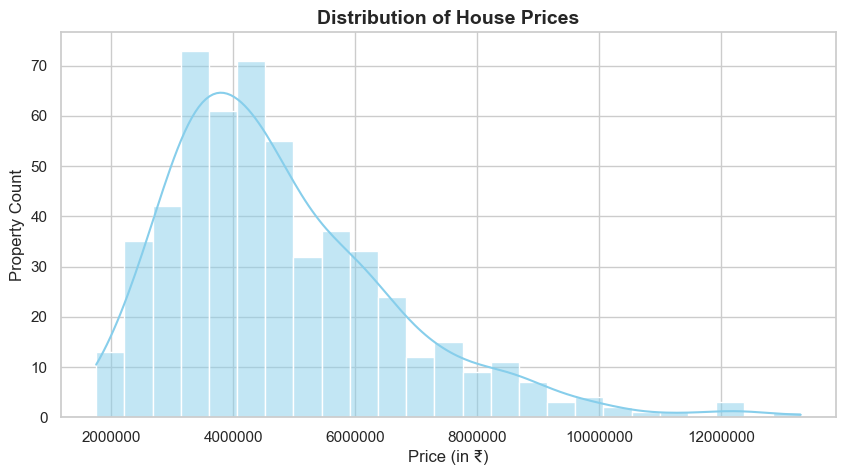

📊 Chart 1 generated and saved successfully as 'charts/chart1_price_distribution.png'


In [18]:
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# Chart 1: Histogram showing the distribution of house prices
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['price'], kde=True, color='skyblue', bins=25)

plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (in ₹)', fontsize=12)
plt.ylabel('Property Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')  # Removes scientific notation exponents

# This line explicitly saves the image as a PNG inside your charts folder
plt.savefig('charts/chart1_price_distribution.png', bbox_inches='tight')
plt.show()

print("📊 Chart 1 generated and saved successfully as 'charts/chart1_price_distribution.png'")

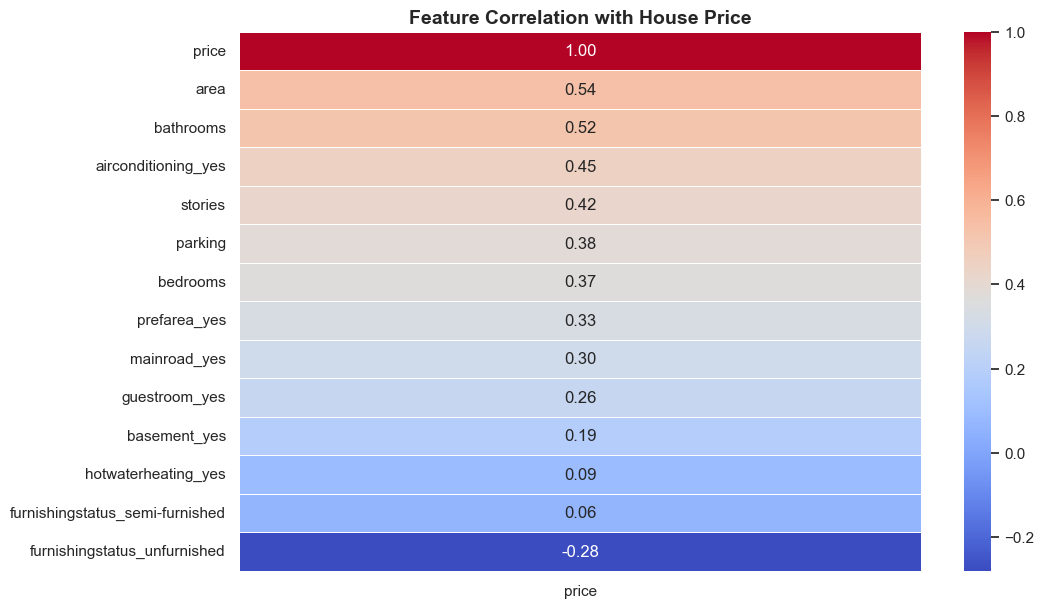

🔥 Chart 2 generated and saved successfully as 'charts/chart2_correlation_heatmap.png'


In [19]:
# ----------------------------------------------------
# Chart 2: Correlation heatmap showing feature impacts
# ----------------------------------------------------
plt.figure(figsize=(11, 7))

# Calculate the correlation matrix on our fully numeric dataframe
correlation_matrix = df_encoded.corr()

# Plotting the heatmap focusing explicitly on the 'price' column impact
sns.heatmap(correlation_matrix[['price']].sort_values(by='price', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation with House Price', fontsize=14, fontweight='bold')

# Save the image into your charts folder
plt.savefig('charts/chart2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("🔥 Chart 2 generated and saved successfully as 'charts/chart2_correlation_heatmap.png'")

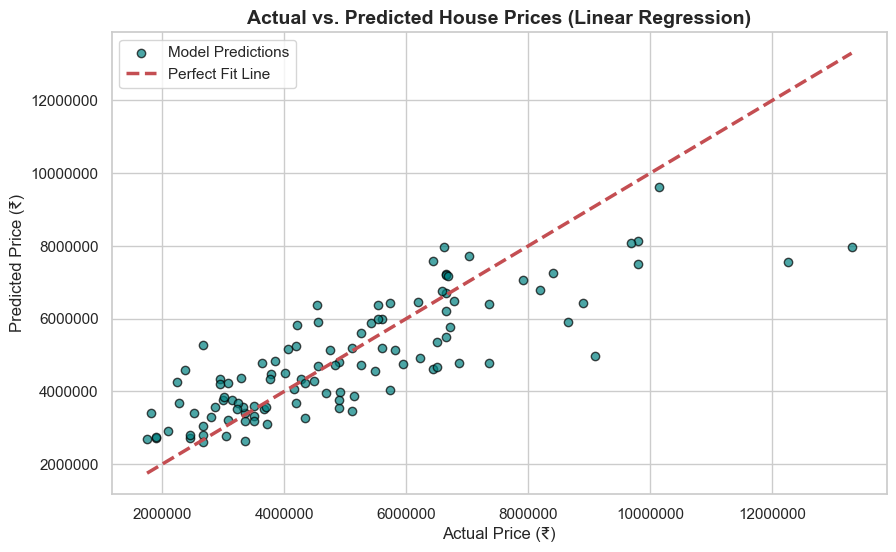

🎯 Chart 3 generated and saved successfully as 'charts/chart3_actual_vs_predicted.png'


In [20]:
# ----------------------------------------------------
# Chart 3: Creative Choice - Actual vs. Predicted Scatter Plot
# ----------------------------------------------------
plt.figure(figsize=(10, 6))

# Extract the predictions from your top-performing Linear Regression model
lr_predictions = lr_model.predict(X_test)

# Plotting the actual vs predicted valuations
plt.scatter(y_test, lr_predictions, alpha=0.7, color='teal', edgecolors='black', label='Model Predictions')

# Ideal 1:1 match reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Perfect Fit Line')

plt.title('Actual vs. Predicted House Prices (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (₹)', fontsize=12)
plt.ylabel('Predicted Price (₹)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')  # Suppresses scientific notation
plt.legend()

# Save the image into your charts folder
plt.savefig('charts/chart3_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

print("🎯 Chart 3 generated and saved successfully as 'charts/chart3_actual_vs_predicted.png'")